#  Social Media User Behavior — ML Pipeline

**Goal:** Predict `sleep_disruption` (multi-class: No impact / Mild / Moderate / Severe)  
from 33 behavioral, demographic, and engagement features.

| | |
|---|---|
| **Rows** | 2 000 |
| **Features** | 33 (numeric + categorical) |
| **Target** | `sleep_disruption` (4 classes) |
| **Models** | Logistic Regression · Random Forest · XGBoost · Gradient Boosting |

---


In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import warnings, joblib, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

print(" All libraries loaded.")


 All libraries loaded.


## 1 · Load & Inspect Data

In [2]:
df = pd.read_csv("social_media_user_behavior.csv")

print(f"Shape: {df.shape}")
print(f"\nDtypes summary:")
print(df.dtypes.value_counts())
df.head(3)


Shape: (2000, 34)

Dtypes summary:
str        19
int64      10
float64     5
Name: count, dtype: int64


,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes


In [3]:
# Quick stats
display(df.describe(include="number").T.style.background_gradient(cmap="Blues", axis=1))


,count,mean,std,min,25%,50%,75%,max
age,2000.000000,26.986000,7.649775,13.000000,22.000000,27.000000,32.000000,57.000000
platforms_used_count,2000.000000,3.010000,1.431756,1.000000,2.000000,3.000000,4.000000,5.000000
daily_usage_hours,2000.000000,2.990650,1.858501,0.500000,1.600000,2.600000,3.900000,12.000000
sessions_per_day,2000.000000,5.024500,2.249985,1.000000,3.000000,5.000000,6.000000,15.000000
avg_session_duration_min,2000.000000,47.547400,51.104393,3.300000,18.975000,34.000000,56.000000,594.000000
followers_count,2000.000000,4153.737500,47935.625651,0.000000,201.750000,688.000000,2320.500000,2110323.000000
following_count,2000.000000,513.998500,851.817900,4.000000,109.000000,249.000000,580.000000,10000.000000
posts_per_week,2000.000000,2.964000,1.679915,0.000000,2.000000,3.000000,4.000000,10.000000
likes_given_per_day,2000.000000,19.883000,4.389527,6.000000,17.000000,20.000000,23.000000,38.000000
comments_per_day,2000.000000,3.991500,1.997354,0.000000,3.000000,4.000000,5.000000,11.000000


## 2 · Exploratory Data Analysis

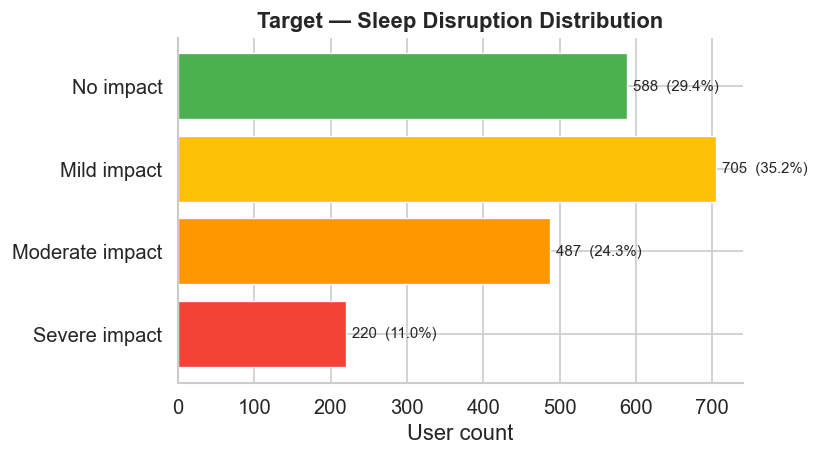

In [4]:
# ── 2a. Target distribution
fig, ax = plt.subplots(figsize=(7, 4))
order = ["No impact", "Mild impact", "Moderate impact", "Severe impact"]
colors = ["#4CAF50", "#FFC107", "#FF9800", "#F44336"]
counts = df["sleep_disruption"].value_counts().reindex(order)
bars = ax.barh(order[::-1], counts[::-1], color=colors[::-1], edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({val/len(df):.1%})", va="center", fontsize=9)
ax.set_xlabel("User count")
ax.set_title("Target — Sleep Disruption Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()


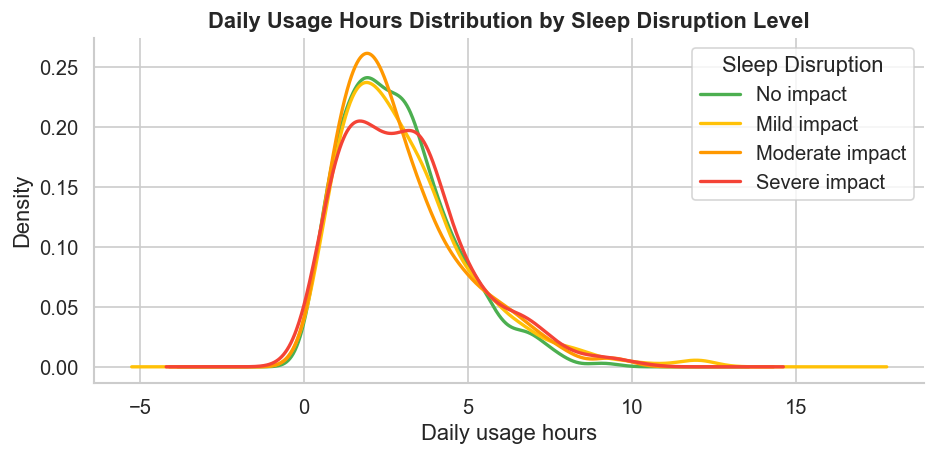

In [5]:
# ── 2b. Daily usage hours by sleep disruption
fig, ax = plt.subplots(figsize=(8, 4))
palette = {"No impact": "#4CAF50", "Mild impact": "#FFC107",
           "Moderate impact": "#FF9800", "Severe impact": "#F44336"}
for label, color in palette.items():
    subset = df[df["sleep_disruption"] == label]["daily_usage_hours"]
    subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
ax.set_xlabel("Daily usage hours")
ax.set_title("Daily Usage Hours Distribution by Sleep Disruption Level", fontweight="bold")
ax.legend(title="Sleep Disruption")
plt.tight_layout()
plt.savefig("usage_by_disruption.png", dpi=150)
plt.show()


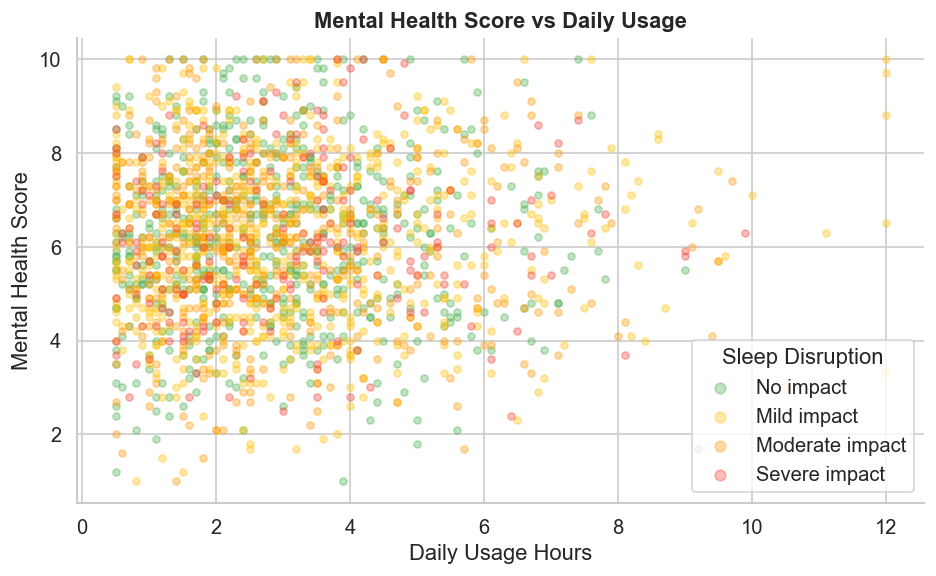

In [6]:
# ── 2c. Mental health score vs daily usage (scatter)
fig, ax = plt.subplots(figsize=(8, 5))
scatter_palette = {"No impact": "#4CAF50", "Mild impact": "#FFC107",
                   "Moderate impact": "#FF9800", "Severe impact": "#F44336"}
for label, color in scatter_palette.items():
    sub = df[df["sleep_disruption"] == label]
    ax.scatter(sub["daily_usage_hours"], sub["self_reported_mental_health_score"],
               alpha=0.35, s=18, label=label, color=color)
ax.set_xlabel("Daily Usage Hours")
ax.set_ylabel("Mental Health Score")
ax.set_title("Mental Health Score vs Daily Usage", fontweight="bold")
ax.legend(title="Sleep Disruption", markerscale=1.5)
plt.tight_layout()
plt.savefig("mental_health_scatter.png", dpi=150)
plt.show()


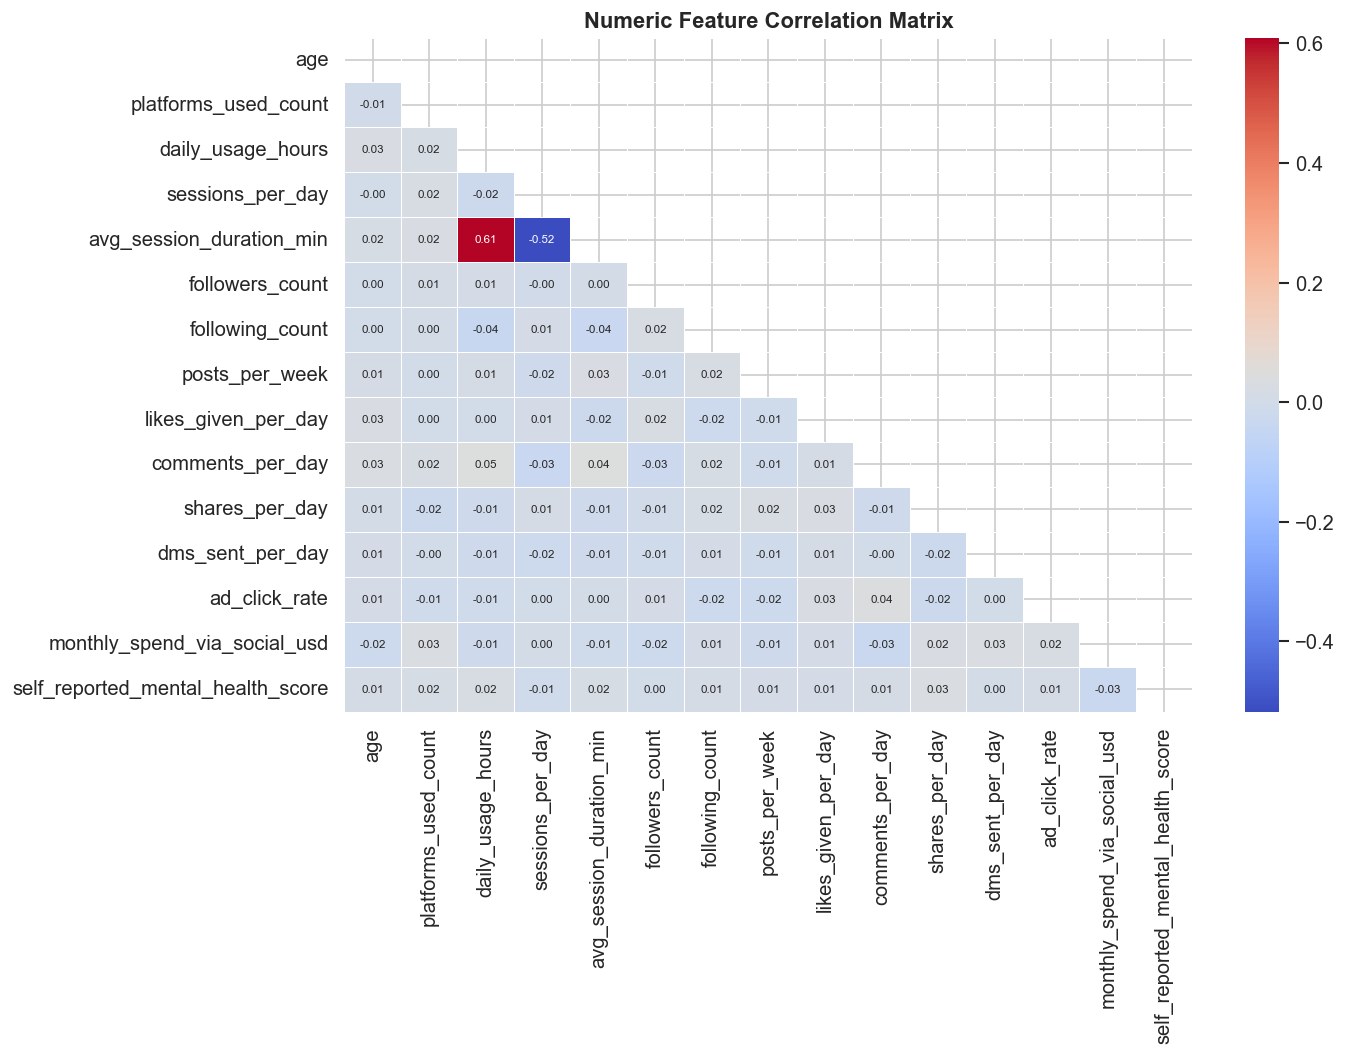

In [7]:
# ── 2d. Correlation heatmap (numeric features)
num_cols = df.select_dtypes("number").columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Numeric Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


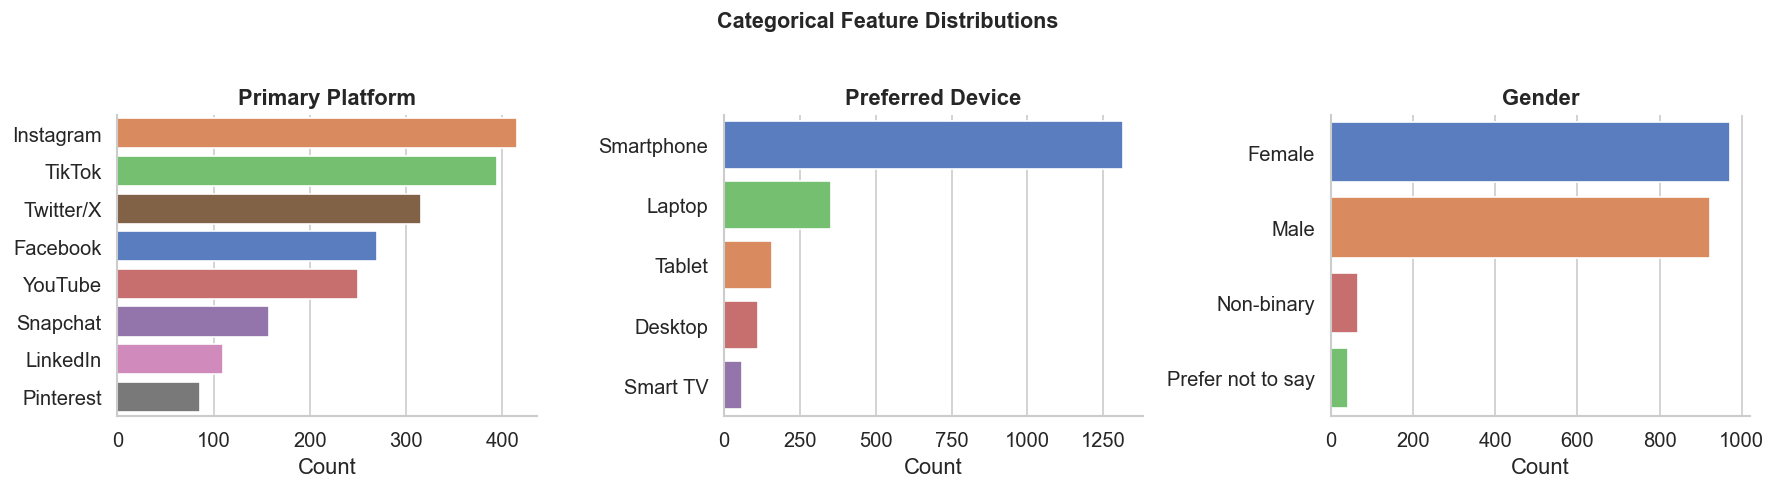

In [8]:
# ── 2e. Top categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["primary_platform", "preferred_device", "gender"]):
    order_vals = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order_vals, palette="muted",
                  hue=col, legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=150)
plt.show()


## 3 · Preprocessing & Feature Engineering

In [9]:
# Drop ID; extract year from join date
df_ml = df.copy()
df_ml["account_age_years"] = pd.to_datetime(df_ml["account_join_date"]).apply(
    lambda x: (pd.Timestamp("2025-01-01") - x).days / 365)
df_ml.drop(columns=["user_id", "account_join_date"], inplace=True)

# Encode target
target_order = ["No impact", "Mild impact", "Moderate impact", "Severe impact"]
le_target = LabelEncoder()
le_target.fit(target_order)
y = le_target.transform(df_ml["sleep_disruption"])
X = df_ml.drop(columns=["sleep_disruption"])

# Split feature types
NUM_COLS = X.select_dtypes("number").columns.tolist()
CAT_COLS = X.select_dtypes("object").columns.tolist()

print(f"Numeric features  : {len(NUM_COLS)}")
print(f"Categorical features: {len(CAT_COLS)}")
print(f"\nTarget classes  : {dict(zip(le_target.classes_, range(4)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")


Numeric features  : 16
Categorical features: 16

Target classes  : {np.str_('Mild impact'): 0, np.str_('Moderate impact'): 1, np.str_('No impact'): 2, np.str_('Severe impact'): 3}

Train: (1600, 32)  |  Test: (400, 32)


In [10]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
])

# Sanity-check shape after transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"Processed train shape: {X_train_proc.shape}")
print(f"Processed test shape : {X_test_proc.shape}")


Processed train shape: (1600, 99)
Processed test shape : (400, 99)


## 4 · Model Training & Comparison

In [11]:
MODELS = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=12,
                                       random_state=SEED, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("pre", preprocessor),
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=5, random_state=SEED))
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocessor),
        ("clf", XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                              use_label_encoder=False, eval_metric="mlogloss",
                              random_state=SEED, n_jobs=-1))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, pipe in MODELS.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring="accuracy", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average="weighted")
    results[name] = {
        "cv_mean": cv_scores.mean(),
        "cv_std":  cv_scores.std(),
        "test_acc": test_acc,
        "test_f1":  test_f1,
        "y_pred":   y_pred,
        "pipe":     pipe,
    }
    print(f"{name:<22} | CV {cv_scores.mean():.3f}±{cv_scores.std():.3f}"
          f" | Test Acc {test_acc:.3f} | F1 {test_f1:.3f}")


Logistic Regression    | CV 0.297±0.021 | Test Acc 0.312 | F1 0.289
Random Forest          | CV 0.348±0.016 | Test Acc 0.360 | F1 0.278
Gradient Boosting      | CV 0.325±0.012 | Test Acc 0.302 | F1 0.290
XGBoost                | CV 0.331±0.029 | Test Acc 0.320 | F1 0.303


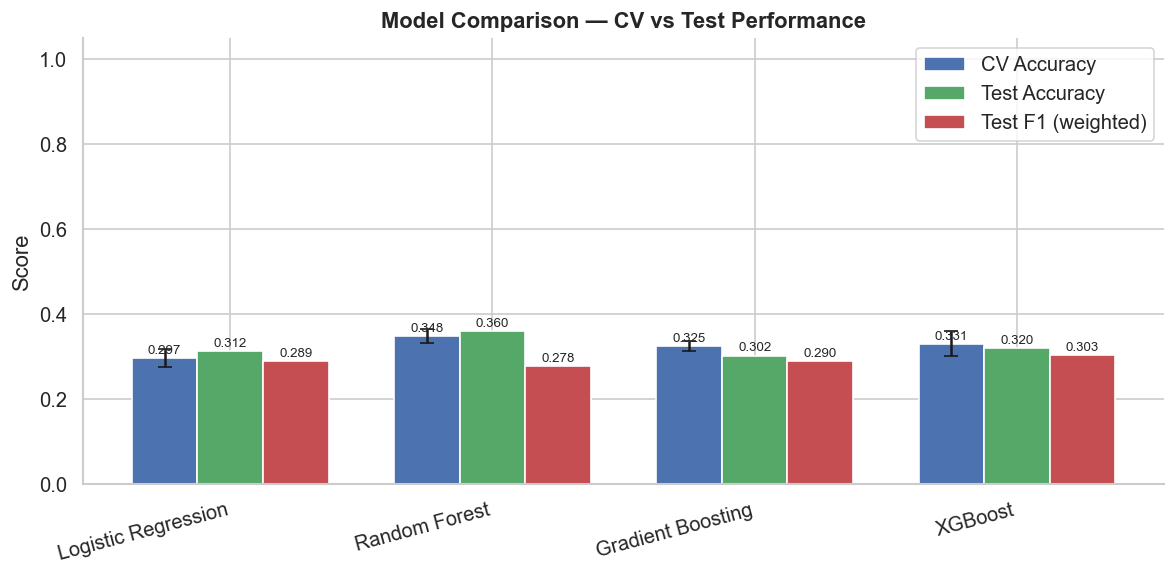

In [12]:
# ── 4a. Model comparison bar chart
model_names = list(results.keys())
cv_means   = [results[m]["cv_mean"]  for m in model_names]
cv_stds    = [results[m]["cv_std"]   for m in model_names]
test_accs  = [results[m]["test_acc"] for m in model_names]
test_f1s   = [results[m]["test_f1"]  for m in model_names]

x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, cv_means,  w, yerr=cv_stds, capsize=4,
            label="CV Accuracy", color="#4C72B0")
b2 = ax.bar(x,     test_accs, w, label="Test Accuracy", color="#55A868")
b3 = ax.bar(x + w, test_f1s,  w, label="Test F1 (weighted)", color="#C44E52")

for bars in (b1, b2, b3):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — CV vs Test Performance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


## 5 · Best Model Deep-Dive

In [14]:
best_name = max(results, key=lambda m: results[m]["test_f1"])
best      = results[best_name]
print(f"  Best model: {best_name}")
print(f"    Test Accuracy : {best['test_acc']:.4f}")
print(f"    Test F1 (w)   : {best['test_f1']:.4f}")

print("\n" + classification_report(
    y_test, best["y_pred"],
    target_names=le_target.classes_))


  Best model: XGBoost
    Test Accuracy : 0.3200
    Test F1 (w)   : 0.3035

                 precision    recall  f1-score   support

    Mild impact       0.36      0.50      0.42       141
Moderate impact       0.28      0.20      0.23        97
      No impact       0.27      0.30      0.28       118
  Severe impact       0.50      0.09      0.15        44

       accuracy                           0.32       400
      macro avg       0.35      0.27      0.27       400
   weighted avg       0.33      0.32      0.30       400



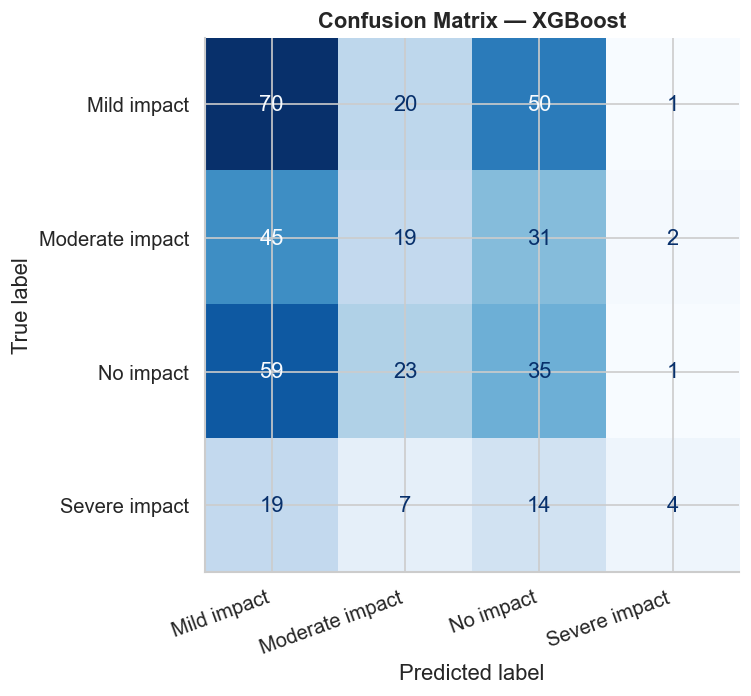

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


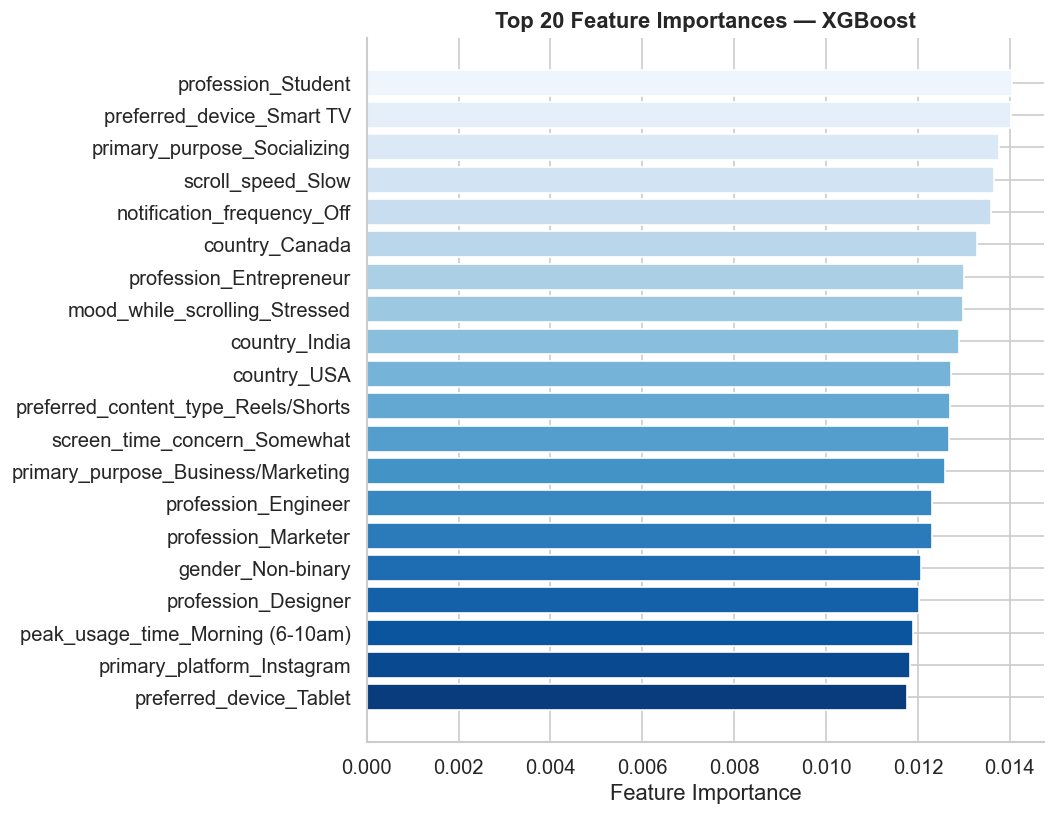

In [16]:
# Feature importances (tree-based) or coefficients (LR)
clf = best["pipe"].named_steps["clf"]
pre = best["pipe"].named_steps["pre"]

# Get feature names after one-hot encoding
ohe_features = (pre.named_transformers_["cat"]
                   .get_feature_names_out(CAT_COLS).tolist())
all_features = NUM_COLS + ohe_features

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    label = "Feature Importance"
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_).mean(axis=0)
    label = "Mean |Coefficient|"

feat_df = (pd.DataFrame({"feature": all_features, "importance": importances})
           .sort_values("importance", ascending=False)
           .head(20))

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_df["feature"][::-1], feat_df["importance"][::-1],
               color=sns.color_palette("Blues_r", 20))
ax.set_xlabel(label)
ax.set_title(f"Top 20 Feature Importances — {best_name}", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()


## 6 · Save Model & Results

In [17]:
# Save best pipeline
joblib.dump(best["pipe"], "best_model.pkl")
joblib.dump(le_target, "label_encoder.pkl")

# Save metrics summary
metrics = {m: {k: v for k, v in r.items() if k not in ("y_pred", "pipe")}
           for m, r in results.items()}
with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print("   best_model.pkl")
print("   label_encoder.pkl")
print("   model_metrics.json")


Saved:
   best_model.pkl
   label_encoder.pkl
   model_metrics.json


## 7 · Inference Example

In [18]:
import joblib

model   = joblib.load("best_model.pkl")
le      = joblib.load("label_encoder.pkl")

# One sample (a new user)
sample = X_test.iloc[[0]].copy()
pred_encoded = model.predict(sample)[0]
pred_proba   = model.predict_proba(sample)[0]

print(f"Input features (first 5):\n{sample.iloc[0, :5].to_dict()}\n")
print(f"Predicted class : {le.inverse_transform([pred_encoded])[0]}")
print(f"\nClass probabilities:")
for cls, prob in zip(le.classes_, pred_proba):
    bar = "█" * int(prob * 30)
    print(f"  {cls:<22} {prob:.3f}  {bar}")


Input features (first 5):
{'age': 13, 'gender': 'Female', 'country': 'Pakistan', 'profession': 'Entrepreneur', 'primary_platform': 'Instagram'}

Predicted class : No impact

Class probabilities:
  Mild impact            0.072  ██
  Moderate impact        0.320  █████████
  No impact              0.573  █████████████████
  Severe impact          0.035  █
